<a href="https://colab.research.google.com/github/curtismutuma-rgb/AI-for-Science-and-Engineering-Short-Course/blob/add-temperature-converter/AI_ML_Disease_Identification_ChestMNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AI/ML for Medical Disease Identification

## Project problem and intended AI/ML outcome

In Week 1, I identified that machine-learning models could help doctors identify and characterize diseases and viruses in everyday healthcare. For this assignment, I narrow that broad idea to a supervised image-classification project: use chest X-rays to flag one or more of 14 thoracic disease labels. The model would support a clinician's review, not make a diagnosis on its own. The selected dataset does not contain virus or pathogen labels, so this project does not identify a specific virus.


## Data needed and selected dataset

### Data needed for the broader problem

A useful medical ML dataset would contain de-identified medical images, reliable clinician-confirmed disease labels, and (where appropriate) relevant clinical context such as age, symptoms, and care setting. To identify a particular virus, it would also need laboratory-confirmed pathogen results, such as PCR test labels. Data should represent different patient groups and hospitals, with patient privacy protected.

### Dataset selected for this assignment

I will use **ChestMNIST**, a public subset of MedMNIST based on NIH ChestX-ray14. It contains 112,120 frontal chest X-rays and 14 report-mined disease labels. The images are provided as 28 × 28 grayscale images, and the standard splits are 78,468 training, 11,219 validation, and 22,433 test images. Each image can have multiple labels. The dataset is useful for a small educational project, but its report-mined labels and reduced image resolution are important limitations. It has no virus/PCR target.

The official MedMNIST API below downloads the dataset in Colab. MedMNIST states that its data are not intended for clinical use. See the [official MedMNIST project](https://medmnist.com/), [official data record](https://doi.org/10.5281/zenodo.10519652), and [MedMNIST v2 paper](https://doi.org/10.1038/s41597-022-01721-8). The MedMNIST release is CC BY 4.0; follow the source's attribution guidance when reusing it.


In [2]:
# Install the official MedMNIST package in the Colab runtime.
!pip -q install medmnist

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 1.4 MB/s eta 0:00:00


Dataset: ChestMNIST
Disease labels: atelectasis, cardiomegaly, effusion, infiltration, mass, nodule, pneumonia, pneumothorax, consolidation, edema, emphysema, fibrosis, pleural, hernia


100%|██████████| 82.8M/82.8M [01:32<00:00, 898kB/s] 


Training images: 78,468
Validation images: 11,219
Test images: 22,433


,sample_index,image_shape,reported_positive_labels,14-value_target_vector
0,0,"(28, 28)",No positive label,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]"
1,1,"(28, 28)",No positive label,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]"
2,2,"(28, 28)",No positive label,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]"
3,3,"(28, 28)",No positive label,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]"
4,4,"(28, 28)",No positive label,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]"


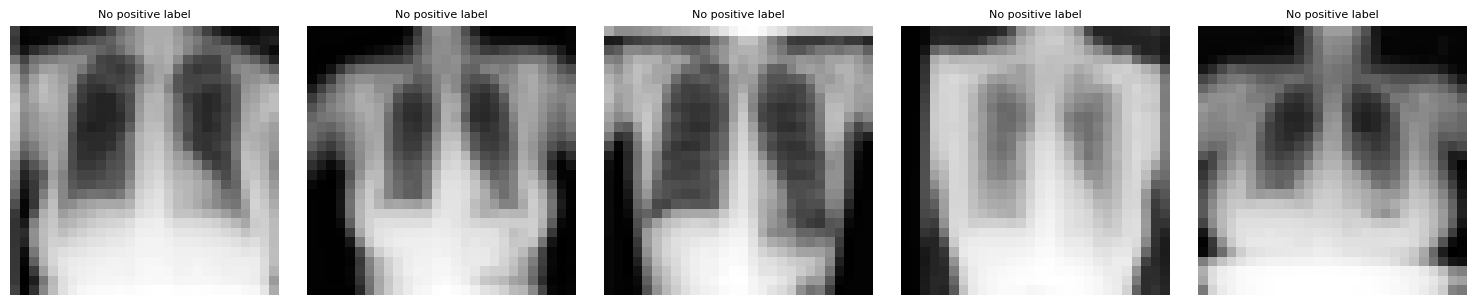

In [3]:
# Import the tools used to load and preview the image data.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from medmnist import ChestMNIST, INFO

# Read the dataset's label names from the official MedMNIST metadata.
dataset_info = INFO["chestmnist"]
label_names = [dataset_info["label"][str(i)] for i in range(len(dataset_info["label"]))]
print("Dataset: ChestMNIST")
print("Disease labels:", ", ".join(label_names))

# Download and load the official training, validation, and test splits.
train_data = ChestMNIST(split="train", download=True)
val_data = ChestMNIST(split="val", download=True)
test_data = ChestMNIST(split="test", download=True)
print(f"Training images: {len(train_data):,}")
print(f"Validation images: {len(val_data):,}")
print(f"Test images: {len(test_data):,}")

# Display a table for the first five training examples and their labels.
preview_rows = []
for index in range(min(5, len(train_data))):
    image, target = train_data[index]
    image_array = np.asarray(image)
    target_vector = np.asarray(target).astype(int).reshape(-1)
    positive_labels = [
        label_names[i] for i, value in enumerate(target_vector) if value == 1
    ]
    preview_rows.append({
        "sample_index": index,
        "image_shape": image_array.shape,
        "reported_positive_labels": ", ".join(positive_labels) if positive_labels else "No positive label",
        "14-value_target_vector": target_vector.tolist(),
    })

display(pd.DataFrame(preview_rows))

# Plot five example chest X-rays so a small portion of the image data is visible.
sample_count = min(5, len(train_data))
fig, axes = plt.subplots(1, sample_count, figsize=(15, 3))
axes = np.atleast_1d(axes)
for index, axis in enumerate(axes):
    image, target = train_data[index]
    target_vector = np.asarray(target).astype(int).reshape(-1)
    positive_labels = [
        label_names[i] for i, value in enumerate(target_vector) if value == 1
    ]
    title = ", ".join(positive_labels[:2]) if positive_labels else "No positive label"
    if len(positive_labels) > 2:
        title += "..."
    axis.imshow(np.asarray(image), cmap="gray")
    axis.set_title(title, fontsize=8)
    axis.axis("off")
plt.tight_layout()
plt.show()

## Potential inputs (features) and output (target)

- **Input/features (X):** grayscale pixel intensities from each 28 × 28 chest X-ray (a 28 × 28 image tensor, or 784 pixel values when flattened). The provided ChestMNIST files do not include patient-level clinical or demographic features.
- **Output/target (y):** a 14-element multi-label vector. Each element is a binary indicator for one reported thoracic disease label; more than one label may be positive for an image. The label names are printed from the dataset metadata in the code cell above.
- **Important boundary:** these labels do not say which virus caused an illness and do not include PCR results. A virus-identification project would need a separate dataset pairing images or clinical data with laboratory-confirmed pathogen labels.


## Proposed ML workflow

```text
[De-identified chest X-rays + reliable labels]
                  ↓
[Check data quality; resize/normalize images]
                  ↓
[Use patient-level train / validation / test splits]
                  ↓
[Train a multi-label image classifier, such as a CNN]
                  ↓
[Choose label thresholds using validation data]
                  ↓
[Evaluate held-out test data: per-label sensitivity, specificity, precision, AUROC]
                  ↓
[Show possible findings to a clinician for review; validate externally]
```

The model would output a probability for each of the 14 labels. The validation set is used to tune thresholds, while the test set is reserved for final evaluation. Because a missed disease can be serious, sensitivity and specificity should be examined for every label, not only overall accuracy. Before any real-world use, the system would need clinical review, testing on data from other hospitals and patient groups, privacy safeguards, and ongoing bias and safety monitoring. This educational dataset must not be used to diagnose patients.


## Submission reminder

Run the notebook cells in Google Colab so the dataset downloads and the preview table and images appear. Then save/download the completed `.ipynb`, upload it to the course-project GitHub repository, open the notebook file on GitHub, and submit that file's URL on Google Classroom. Click **Turn in** in Classroom to complete the submission.